# Preparação para Atividade Avaliativa - Treinamento de MLPs e CNNs

O objetivo desta atividade é se preparar para a atividade avaliativa. Para isto, seleciona uma das bases de dados utilizadas anteriormente (mnist, doenças em folhas de feijão ou raios-x) e siga os passos indicados abaixo. Em caso de dúvida, veja o notebook que demonstra como treinar CNNs. 

**Importante**: Use o google colab para treinar as CNNs usando GPUs.


---

Imports básicos

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sns.set_style('darkgrid')


### Obtenção dos Dados

Obtenha os dados usando a biblioteca kagglehub ou lendo os dados do disco.

In [2]:
# resposta
import torchvision.datasets
import torchvision.transforms.v2 as v2
ds_path = "~/.cache/mnist_dataset"

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.5, 0.5, 0.5] , [0.5, 0.5, 0.5])
])

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### Construção do Dataset do Pytorch

Implemente uma classe para representar o dataset do pytorch ou usa função pré-defina como [ImageFolder](https://debuggercafe.com/pytorch-imagefolder-for-training-cnn-models/).

A classe deve receber como entrada um atributo `transform` que realize pré-processamento nos dados e *data augmentation* no treino.


In [3]:
# resposta


train_ds = torchvision.datasets.MNIST(ds_path, train=True, transform=transform, download=True)
test_ds = torchvision.datasets.MNIST(ds_path, train=False, transform=transform, download=True)

print(len(train_ds))
print(len(test_ds))

NameError: name 'torchvision' is not defined

### Construção do Dataloader e Visualização de Exemplos

Crie dataloaders.

In [31]:
# resposta

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

Mostra algumas imagens de exemplo.

torch.Size([3, 28, 28])


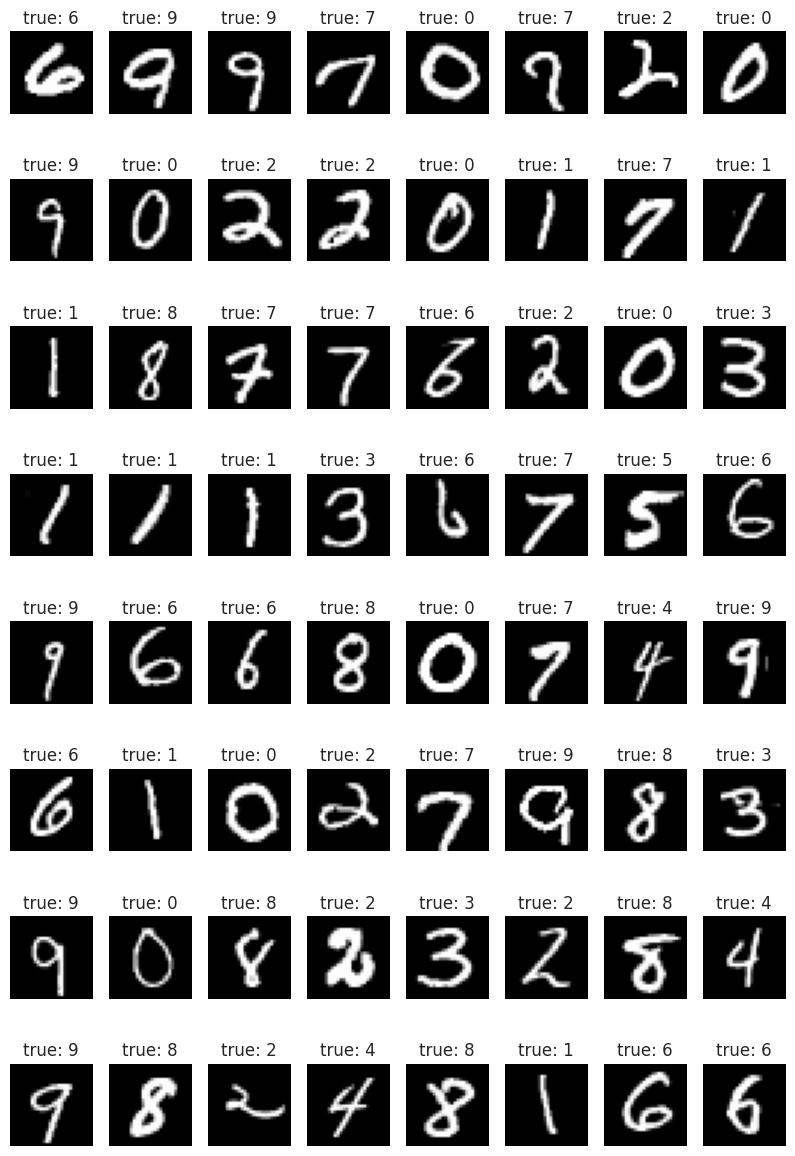

In [35]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch(images, labels):
    n = len(images)
    grid_size = int(np.ceil(np.sqrt(n)))

    for idx in range(n):
        plt.subplot(grid_size, grid_size, idx + 1)
        img = images[idx].numpy()

        # muda do formato [channels, rows, cols] do torch para [rows, cols, channels]
        img = np.transpose(img, (1, 2, 0))
        img -= img.min()
        img /= img.max()

        plt.imshow(img)
        plt.grid(False)
        plt.axis('off')
        title = f'true: {labels[idx].numpy()}'
        plt.title(title)

# get some random training images
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(images[0].size())

plt.close('all')
plt.figure(figsize=(10, 15))
show_batch(images, labels)
plt.show()


### Definição do Modelo

Construa uma rede MLP usando `nn.Sequential`.

In [37]:
# resposta

mlp = nn.Sequential (
    nn.Flatten(),

    nn.Linear(3*28*28, 128),
    nn.ReLU(),

    nn.Linear(128, 128),
    nn.ReLU(),

    nn.Dropout(0.2),
    nn.Linear(128, 10)
)

mlp = mlp.to(device)

mlp

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=2352, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=128, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=128, out_features=10, bias=True)
)

Construa uma rede convolucional usando `nn.Sequential`.

In [38]:
# resposta

cnn = nn.Sequential(
    nn.Conv2d(3, 16, 3, padding=1),  # 16*28*28
    nn.ReLU(),
    nn.MaxPool2d(2, 2),              # 16*14*14

    nn.Conv2d(16, 32, 3, padding=1), # 32*14*14
    nn.ReLU(),
    nn.MaxPool2d(2, 1),               # 32*13*13

    nn.Flatten(),

    nn.Linear(32*13*13, 128),
    nn.ReLU(),

    nn.Linear(128, 10)
)

cnn = cnn.to(device)

cnn

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=5408, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)

Carregue uma rede pré-treinada e configure-a para *feature extraction*.

In [55]:
# resposta
import torchvision.models as models

fe = models.mobilenet_v3_large(weights="IMAGENET1K_V2")

for param in fe.parameters():
    param.requires_grad = False

ins = fe.classifier[3].in_features
fe.classifier[3] = nn.Linear(ins, 10)

for param in fe.classifier.parameters():
    param.requires_grad = True

fe.to(device)

fe

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kern

Carregue uma rede pré-treinada e configure-a para *fine-tuning*.

In [56]:
# resposta

ft = models.mobilenet_v3_large(weights="IMAGENET1K_V2")

ins = ft.classifier[3].in_features
ft.classifier[3] = nn.Linear(ins, 10)

ft.to(device)
ft

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kern

### Treinamento e Avaliação

Escreva uma função para treinamento do modelo que receba como entrada o modelo, o dataloader de treino, o otimizador, a função de perda e o número de épocas. A função deve mostrar na tela como a acurácia evoluiu ao longo do treinamento.

In [49]:
# resposta
from sklearn.metrics import accuracy_score

criterion = nn.CrossEntropyLoss()

def train(model, loader, optimizer, criterion, n_epochs):
    all_loss = []
    all_accuracy = []

    model.train()
    for i in range(n_epochs):
        all_labels = []
        all_preds = []
        mean_loss = []
        for batch in loader:
            data, labels = batch
            all_labels.extend(labels)
            data = data.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion( outputs, labels)
            loss.backward()

            optimizer.step()

            mean_loss.append(loss.cpu().detach().numpy())

            all_preds.extend(list(np.argmax(outputs.cpu().detach().numpy(), axis=-1)))
        acc = accuracy_score(all_labels, all_preds)
        print(f"Epoch {i}: {acc:.2f}")
        all_accuracy.append(acc)
        all_loss.append(np.mean(mean_loss))
    return all_accuracy, all_loss

Escreva uma função para avaliação do modelo que receba como entrada o modelo e o dataloader de teste. A função deve mostrar na tela as métricas de acurácia, precision, recall e f1-score. 

In [50]:
# resposta
from sklearn.metrics import classification_report


def evaluation(model, loader):
    model.eval()
    with torch.no_grad():
        all_labels = []
        all_preds = []
        for batch in loader:
            data, labels = batch
            all_labels.extend(labels)
            data = data.to(device)

            outputs = model(data)
            all_preds.extend(list(np.argmax(outputs.cpu().detach().numpy(), axis=-1)))
        print(classification_report(all_labels, all_preds))

Use as funções para treinar e avaliar a rede MLP.


In [51]:
# resposta

mlp_optim = optim.Adam(mlp.parameters(), 1e-3)
acc, loss = train(mlp, train_loader, mlp_optim, criterion, 10)
evaluation(mlp, test_loader)

Epoch 0: 0.89
Epoch 1: 0.94
Epoch 2: 0.95
Epoch 3: 0.96
Epoch 4: 0.97
Epoch 5: 0.97
Epoch 6: 0.97
Epoch 7: 0.97
Epoch 8: 0.97
Epoch 9: 0.98
Epoch 10: 0.98
Epoch 11: 0.98
Epoch 12: 0.98
Epoch 13: 0.98
Epoch 14: 0.98
Epoch 15: 0.98
Epoch 16: 0.98
Epoch 17: 0.98
Epoch 18: 0.98
Epoch 19: 0.98
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.97      0.99      0.98      1135
           2       0.96      0.99      0.97      1032
           3       0.95      0.98      0.96      1010
           4       0.98      0.95      0.96       982
           5       0.98      0.92      0.95       892
           6       0.99      0.97      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.94      0.99      0.96       974
           9       0.96      0.95      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weight

In [ ]:
plt.plot(acc, "-o")
plt.plot(loss, "-o")
plt.legend(["Accuracy", "Loss"])

Use as funções para treinar e avaliar a CNN que você construiu.


In [52]:
# resposta

cnn_optim = optim.Adam(cnn.parameters(), 1e-3)
acc, loss = train(cnn, train_loader, cnn_optim, criterion, 10)
evaluation(cnn, test_loader)

Epoch 0: 0.96
Epoch 1: 0.99
Epoch 2: 0.99
Epoch 3: 0.99
Epoch 4: 0.99
Epoch 5: 1.00
Epoch 6: 1.00
Epoch 7: 1.00
Epoch 8: 1.00
Epoch 9: 1.00
Epoch 10: 1.00
Epoch 11: 1.00
Epoch 12: 1.00
Epoch 13: 1.00
Epoch 14: 1.00
Epoch 15: 1.00
Epoch 16: 1.00
Epoch 17: 1.00
Epoch 18: 1.00
Epoch 19: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      0.99      1.00      1135
           2       1.00      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.97      1.00      0.98       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weight

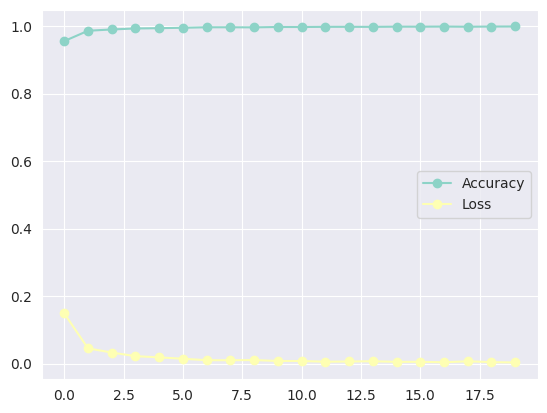

In [53]:
plt.plot(acc, "-o")
plt.plot(loss, "-o")
plt.legend(["Accuracy", "Loss"])

Use as funções para treinar e avaliar a CNN configurada para *feature extraction*. Lembre-se definir no otimizador que apenas as últimas camadas devem ser treinadas.


In [57]:
# resposta
fe_optim = optim.Adam(fe.classifier.parameters(), 1e-4)
acc, loss = train(fe, train_loader, fe_optim, criterion, 10)
evaluation(fe, test_loader)

Epoch 0: 0.56
Epoch 1: 0.66
Epoch 2: 0.68
Epoch 3: 0.69
Epoch 4: 0.69
Epoch 5: 0.70
Epoch 6: 0.71
Epoch 7: 0.71
Epoch 8: 0.72
Epoch 9: 0.72
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       980
           1       0.93      0.93      0.93      1135
           2       0.69      0.66      0.68      1032
           3       0.67      0.65      0.66      1010
           4       0.73      0.77      0.75       982
           5       0.60      0.55      0.58       892
           6       0.72      0.79      0.75       958
           7       0.76      0.75      0.75      1028
           8       0.69      0.70      0.69       974
           9       0.74      0.72      0.73      1009

    accuracy                           0.74     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.74      0.74      0.74     10000



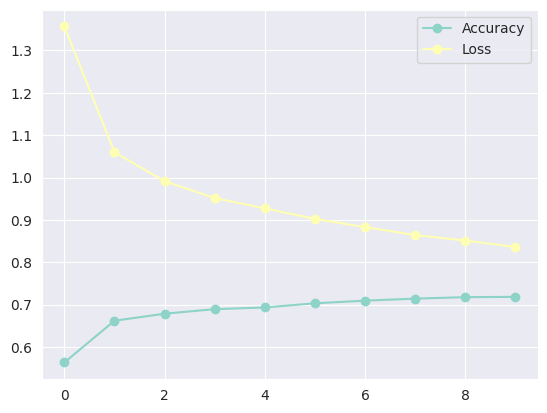

In [58]:
plt.plot(acc, "-o")
plt.plot(loss, "-o")
plt.legend(["Accuracy", "Loss"])

Use as funções para treinar e avaliar a CNN configurada para *fine-tuning*. 


In [59]:
# resposta
ft_optim = optim.Adam(ft.parameters(), 1e-4)
acc, loss = train(ft, train_loader, ft_optim, criterion, 10)
evaluation(ft, test_loader)

Epoch 0: 0.79
Epoch 1: 0.95
Epoch 2: 0.97
Epoch 3: 0.98
Epoch 4: 0.99
Epoch 5: 0.99
Epoch 6: 0.99
Epoch 7: 0.99
Epoch 8: 0.99
Epoch 9: 0.99
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.98      0.99      1010
           4       0.96      0.99      0.98       982
           5       0.97      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       0.99      0.97      0.98      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.96      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.98      0.99      0.98     10000
weighted avg       0.99      0.99      0.99     10000



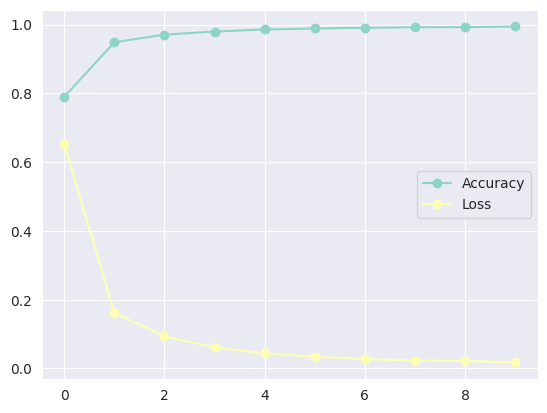

In [60]:
plt.plot(acc, "-o")
plt.plot(loss, "-o")
plt.legend(["Accuracy", "Loss"])

## Análise Crítica

Escreva um parágrafo discutindo os seguintes itens: 

1. Como a acurácia evoluiu ao longo do treinamento para os diferentes modelos? Quais modelos alcançaram uma boa performance no treino? Caso algum modelo tenha alcançado uma acurácia mais de 10% inferior aos demais, dê hipóteses que possam justificar este fenômeno.

2. Os modelos generalizaram? Qual modelo alcançou melhor performance no conjunto de teste? Qual modelo você escolheria para implantar em um ambiente real considerando a tarefa específica? Justifique sua escolha.

3. Explique como as métricas precision e recall por classe devem ser interpretadas e o que podemos concluir avaliando estes valores para os diferentes modelos, e.g., o modelo priorizou uma classe sobre as demais? Alguma classe é raramente selecionada pelo modelo? 




Adiciona sua resposta aqui...
